<a href="https://colab.research.google.com/github/zhifengStephen/QRcodeCreation/blob/main/PracW4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LINEAR REGRESSION & LOGISTIC REGRESSION

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from  sklearn.linear_model import LinearRegression

# Mount google colab to drive to access to the dataset (comment if you don't use Colab + Drive)
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


## Q1

### (a)

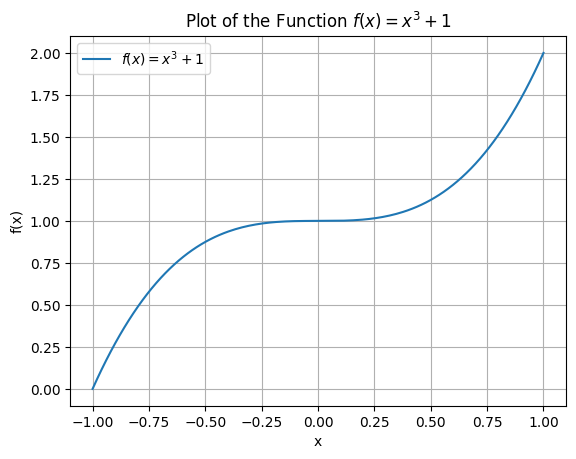

In [2]:
# TODO: Define the function
def f(x):
    return x**3 + 1

# TODO: Generate x values in the specified domain
x_values = np.linspace(-1, 1, 200)

# TODO: Calculate corresponding y values using the function
y_values = f(x_values)

# Plot the function
plt.plot(x_values, y_values, label=r'$f(x) = x^3 + 1$')
plt.title('Plot of the Function $f(x) = x^3 + 1$')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

### (b)

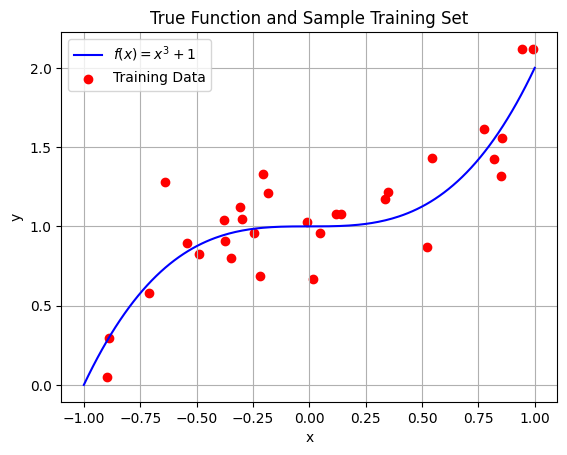

In [3]:
# TODO: Generate 30 random x values in the specified domain
np.random.seed(50)  # for reproducibility
sample_training_x = np.random.uniform(-1,1,30)

# TODO: Calculate corresponding y values using the true function and add Gaussian noise
noise = np.random.normal(0,0.2,30)
sample_training_y = f(sample_training_x)+noise
# Plot the true function
plt.plot(x_values, y_values, label=r'$f(x) = x^3 + 1$', color='blue')

# Plot the noisy data points
plt.scatter(sample_training_x, sample_training_y, color='red', label='Training Data')

# Add labels and legend
plt.title('True Function and Sample Training Set')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

### (c)

Training Set Sum of Squares Error: 2.08752648234433


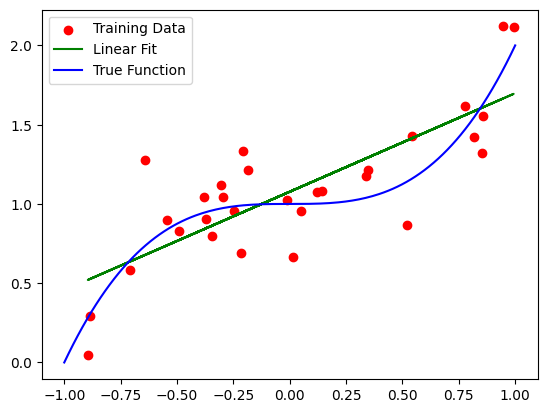

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# TODO: Reshape the data for sklearn (if needed)
X=sample_training_x.reshape(-1,1)
y=sample_training_y

# TODO: Perform linear regression
model=LinearRegression()
model.fit(X,y)

# TODO: Predict y values using the linear model
y_pred=model.predict(X)

# TODO: Calculate the sum of squares error
mse = np.sum((y-y_pred)**2)
print(f'Training Set Sum of Squares Error: {mse}')

plt.scatter(X, y, color='red', label='Training Data')
plt.plot(X, y_pred, color='green', label='Linear Fit')
plt.plot(x_values, y_values, color='blue', label='True Function')
plt.legend()
plt.show()

### (d)

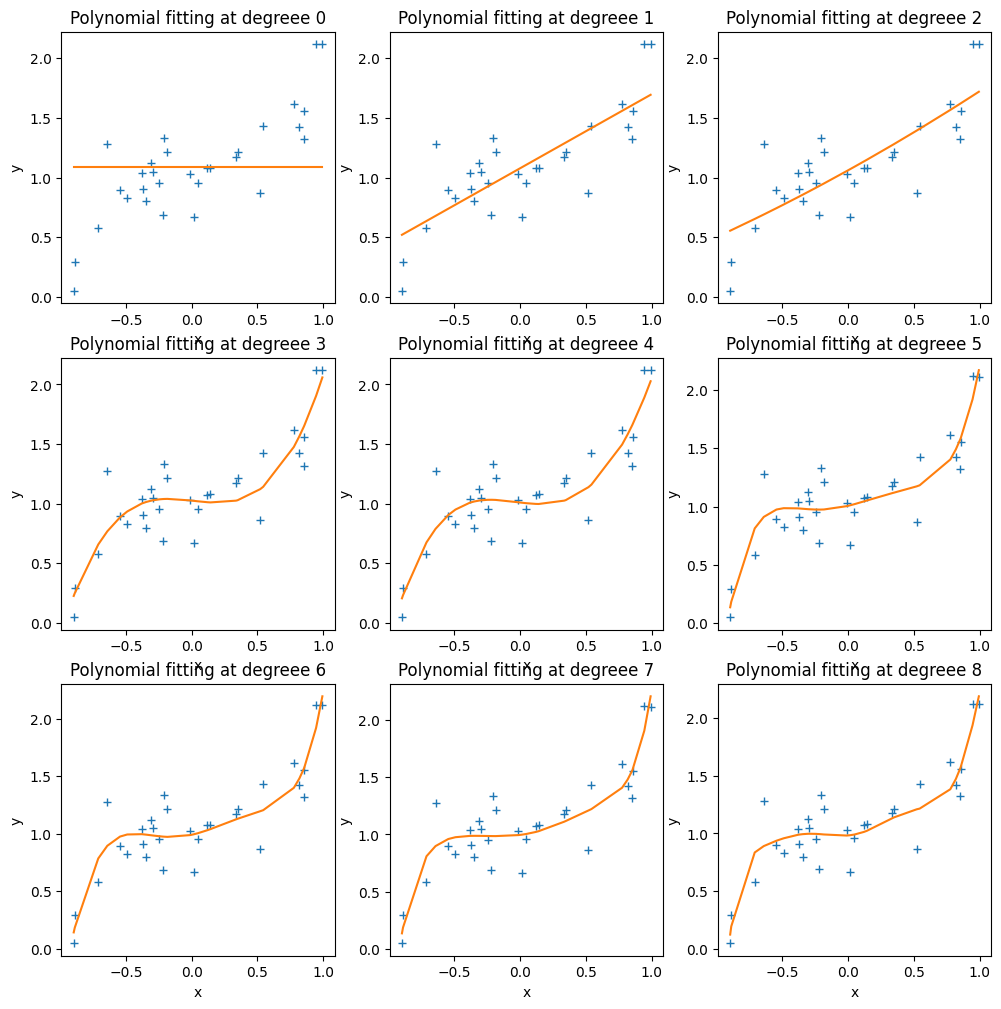

In [5]:
# Perform polynomial regression
from sklearn.preprocessing import PolynomialFeatures

mses = [] # Store MSE for each degree for visualization (optional)

plt.figure(figsize=(12, 12))

X=sample_training_x.reshape(-1,1)
y=sample_training_y

sort_idx=np.argsort(sample_training_x)
sample_training_x_sorted=sample_training_x[sort_idx]
X_sorted=sample_training_x_sorted.reshape(-1,1)

# Experiment with different polynomial orders
for degree in range(9):
  plt.subplot(3, 3,degree + 1)  # Creating matplotlib frame for plotting

  poly=PolynomialFeatures(degree=degree)
  X_poly=poly.fit_transform(X)
  X_sorted_poly=poly.transform(X_sorted)

  # TODO: Polynomial regression
  model=LinearRegression()
  model.fit(X_poly,y)

  # TODO: Predict y values using the polynomial model
  pred_y=model.predict(X_poly)
  pred_y_sorted=model.predict(X_sorted_poly)

  # TODO: Calculate the sum of squares error
  mse=np.sum((y-pred_y)**2)
  mses.append(mse)

  # Plot the polynomial function for current degree (remember to sort the x_train and sample_training_y_pred of x_train for a nice visualization)
  plt.plot(sample_training_x, sample_training_y, '+')
  plt.plot(sample_training_x_sorted, pred_y_sorted)
  plt.xlabel('x')
  plt.ylabel('y')
  plt.title('Polynomial fitting at degreee %d' %degree)

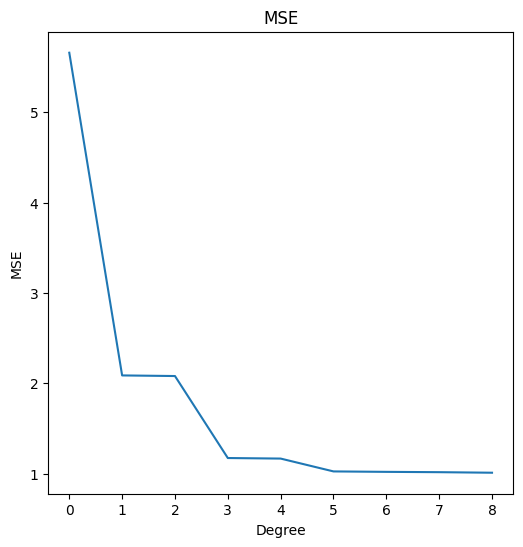

In [6]:
# Plot MSE
plt.figure(figsize=(6,6))
plt.plot(np.arange(0, 9, 1), mses)
plt.title('MSE')
plt.xlabel('Degree')
plt.ylabel('MSE')
plt.show()

## Q2

### (b)

In [28]:
# Load and define dataset
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/pokemonregr.csv') # if use Colab + Drive, specify the full path

# TODO: Handle missing data - impute/drop/etc. (justify your choices)
print(data.isnull().sum())
data=data.dropna()
print(data.isnull().sum())
data.head()

# TODO: Define X, y
y=data["weight_kg"]
x=data.drop(columns=["weight_kg"])

# TODO: Define linear regression model
model=LinearRegression()
model.fit(x,y)

attack         0
defense        0
height_m      20
sp_attack      0
sp_defense     0
speed          0
weight_kg     20
dtype: int64
attack        0
defense       0
height_m      0
sp_attack     0
sp_defense    0
speed         0
weight_kg     0
dtype: int64


LinearRegression()

### (c)

In [21]:
# TODO: Coefficients of Linear Model (hint: look at the document of LinearRegression() in sklearn)
print("Intercept:",model.intercept_)
print("coefficients:",model.coef_)

Intercept: -56.3945821460584
coefficients: [ 3.77397553e-01  5.67721520e-01  5.35146255e+01  2.45998765e-02
  1.53453033e-01 -4.21539817e-01]


### (e)

In [29]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression

# TODO: Normalize feature
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(x)
# TODO: Define X, y for normalized features
X_norm=X_scaled
y_norm=y
# TODO: Define linear regression model
model_norm=LinearRegression()
model_norm.fit(X_norm, y_norm)
# TODO: Coefficients of Linear Model (hint: look at the document of LinearRegression() in sklearn)
print("Intercept:",model_norm.intercept_)
# Fixed: Using x.columns (the DataFrame) instead of X.columns (the numpy array)
for name, coef in zip(x.columns, model_norm.coef_):
  print(f"{name}:{coef}")

Intercept: -45.1101638823217
attack:67.93155956362824
defense:127.73734202508277
height_m:770.610607120215
sp_attack:4.52637728371127
sp_defense:32.22513703329801
speed:-73.76946805132977


## Q3

### (a)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Load dataset
w3classif = pd.read_csv('w3classif.csv', header=None) # if use Colab + Drive, specify the full path

# TODO: Define X, y

# TODO: Standardize the features (optional but often recommended for logistic regression)

# TODO: Create and fit the logistic regression model

# Display the model parameters (coefficients and intercept)
print("Model Coefficients:", logreg_model.coef_)
print("\nModel Intercept:",logreg_model.intercept_)

### (b)

In [ ]:
# TODO: Standardize the test data point using the same scaler

# TODO: Predict the probability of class 1 for the test data point
probability_y1 = ...

print("Probability p(y' = 1 | x'):", probability_y1[0])

### (c)

In [ ]:
# Generate a meshgrid of points for plotting the decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Standardize the meshgrid points using the same scaler
meshgrid_points = np.c_[xx.ravel(), yy.ravel()]
meshgrid_points_scaled = scaler.transform(meshgrid_points)

# TODO: Predict the class labels for the meshgrid points

# TODO: Reshape the predictions to match the shape of the meshgrid

# Plot the decision boundary and data points
plt.contourf(xx, yy, predictions, cmap='RdYlBu', alpha=0.5)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', edgecolors='k', marker='o', s=100)

# Plot labels and title
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary')

# Show the plot
plt.show()